# Step 11 — Inference

Reload the original **Qwen2.5-VL-3B-Instruct** model and attach the fine-tuned LoRA adapters to reconstruct the complete model. Run inference on the **test dataset** using the same chat template and processor used during training to ensure consistency. Generate answers for every test sample and save the image path, question, prediction, and ground-truth answer into a JSON file for evaluation.

In [ ]:
# Import required libraries
import os
import copy
import json
import torch
from tqdm import tqdm
from peft import PeftModel
import pandas as pd
from transformers import AutoProcessor,Qwen2_5_VLForConditionalGeneration,BitsAndBytesConfig
from qwen_vl_utils import process_vision_info

# Define model and adapter paths
MODEL_ID="Qwen/Qwen2.5-VL-3B-Instruct"
ADAPTER_PATH="/kaggle/working/qwen2.5vl_lora/adapter"
TEST_JSON="/kaggle/input/datasets/bbeastboy/assamese-instrument-vlm-datasetqwen2-5-vl-3b/kaggle_dataset32/test.jsonl"
OUTPUT_JSON="/kaggle/working/test_predictions.json"
FINAL_VQA_CSV="/kaggle/input/datasets/bbeastboy/assamese-instrument-vlm-datasetqwen2-5-vl-3b/kaggle_dataset32/final_vqa.csv"
IMAGE_ROOT="/kaggle/input/datasets/bbeastboy/assamese-instrument-vlm-datasetqwen2-5-vl-3b/kaggle_dataset32"

# Configure 4-bit inference
bnb_config=BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

# Load processor
processor=AutoProcessor.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    min_pixels=224*28*28,
    max_pixels=384*28*28
)

# Load base model
base_model=Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map={"":0},
    trust_remote_code=True
)

# Attach LoRA adapter
model=PeftModel.from_pretrained(
    base_model,
    ADAPTER_PATH
)

# Switch to evaluation mode
model.eval()

# Load test samples
test_samples=[]

with open(TEST_JSON,"r",encoding="utf-8") as f:
    for line in f:
        test_samples.append(json.loads(line))

# Load final_vqa.csv metadata
metadata_df=pd.read_csv(FINAL_VQA_CSV)

# Keep only test rows
metadata_df=metadata_df[metadata_df["split"]=="test"]

# Build lookup table
metadata_lookup={}

for _,row in metadata_df.iterrows():

    key=(
        row["image_name"],
        row["question"]
    )

    metadata_lookup[key]={
        "instrument":row["instrument"],
        "question_id":row["question_id"],
        "concept":row["concept"]
    }

predictions=[]

# Run inference
with torch.inference_mode():
    
    for sample in tqdm(test_samples):

        # Create a copy so the original JSON is unchanged
        messages=copy.deepcopy(sample["messages"])

        # Convert relative image path to absolute Kaggle path
        messages[1]["content"][0]["image"]=os.path.join(
            IMAGE_ROOT,
            messages[1]["content"][0]["image"]
        )

        image_inputs,video_inputs=process_vision_info(messages)

        prompt=processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        inputs=processor(
            text=[prompt],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt"
        ).to(model.device)

        generated_ids=model.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False
        )

        generated_ids=generated_ids[:,inputs.input_ids.shape[1]:]

        prediction=processor.batch_decode(
            generated_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True
        )[0]

        # Extract sample information
        image_path=messages[1]["content"][0]["image"]

        image_name=os.path.basename(image_path)

        question=messages[1]["content"][1]["text"]

        ground_truth=messages[2]["content"][0]["text"]

        # Get metadata from final_vqa.csv
        metadata=metadata_lookup[(image_name,question)]

        predictions.append({
            "image":image_path,
            "instrument":metadata["instrument"],
            "question_id":metadata["question_id"],
            "concept":metadata["concept"],
            "question":question,
            "ground_truth":ground_truth,
            "prediction":prediction.strip()
        })

# Save predictions
with open(OUTPUT_JSON,"w",encoding="utf-8") as f:
    json.dump(predictions,f,indent=4,ensure_ascii=False)

print(f"Saved {len(predictions)} predictions to {OUTPUT_JSON}")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

100%|██████████| 315/315 [17:08<00:00,  3.27s/it]

Saved 315 predictions to /kaggle/working/test_predictions.json


# Step 12 — LAVE Evaluation

Evaluate the fine-tuned model using **LAVE (LLM-as-a-Verifier Evaluation)** with **Gemini 2.5 Flash** as the judge. For each test sample, compare the generated answer against the reference answer while considering the question context, then assign a score between **0.0** (incorrect) and **1.0** (perfectly correct). Finally, compute the overall average LAVE score and analyze performance separately for each **instrument** and **question concept** using the metadata saved during inference.

In [ ]:
# Import required libraries
import os
import json
import time
import pandas as pd
import google.generativeai as genai
from tqdm import tqdm

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GOOGLE_API_KEY")


# Configure Gemini API
genai.configure(api_key=secret_value_0)
judge_model=genai.GenerativeModel("gemini-3.1-flash-lite")

# Define file paths
PREDICTIONS_JSON="/kaggle/working/test_predictions.json"
OUTPUT_JSON="/kaggle/working/lave_results.json"

# Load prediction file
with open(PREDICTIONS_JSON,"r",encoding="utf-8") as f:
    predictions=json.load(f)

# Store evaluation results
results=[]

# Evaluate every prediction
for sample in tqdm(predictions):

    prompt=f"""
You are an expert evaluator for Visual Question Answering.

Compare the predicted answer with the reference answer based on factual correctness, semantic similarity, and completeness.

Question:
{sample['question']}

Ground Truth:
{sample['ground_truth']}

Predicted Answer:
{sample['prediction']}

Return ONLY valid JSON in this exact format:

{{
  "score": 0.95,
  "reason": "Short explanation."
}}

Rules:
- score must be between 0.0 and 1.0
- 1.0 = perfectly correct
- 0.8 = mostly correct
- 0.5 = partially correct
- 0.2 = mostly incorrect
- 0.0 = completely incorrect

Do not output anything except the JSON object.
"""

    while True:

        try:

            response=judge_model.generate_content(prompt)

            text=response.text.strip()

            if text.startswith("```"):
                text=text.replace("```json","").replace("```","").strip()

            result=json.loads(text)

            score=float(result["score"])

            score=max(0.0,min(1.0,score))

            reason=result["reason"]

            break

        except Exception as e:

            if "429" in str(e):

                print("Rate limit reached. Waiting 35 seconds...")

                time.sleep(35)

                continue

            score=None

            reason=str(e)

            break

    if score is None:
        continue

    results.append({
        "instrument":sample["instrument"],
        "question_id":sample["question_id"],
        "concept":sample["concept"],
        "question":sample["question"],
        "ground_truth":sample["ground_truth"],
        "prediction":sample["prediction"],
        "lave_score":score,
        "reason":reason
    })

    time.sleep(5)

# Save detailed LAVE results
with open(OUTPUT_JSON,"w",encoding="utf-8") as f:
    json.dump(results,f,indent=4,ensure_ascii=False)

# Create dataframe
df=pd.DataFrame(results)

# Compute overall LAVE
overall_lave=df["lave_score"].mean()

# Compute instrument-wise LAVE
instrument_lave=df.groupby("instrument")["lave_score"].mean().sort_values(ascending=False)

# Compute concept-wise LAVE
concept_lave=df.groupby("concept")["lave_score"].mean().sort_values(ascending=False)

# Display results
print(f"Overall LAVE Score : {overall_lave:.4f}")

print("\nInstrument-wise LAVE")
print(instrument_lave)

print("\nConcept-wise LAVE")
print(concept_lave)

100%|██████████| 315/315 [30:10<00:00,  5.75s/it]

Overall LAVE Score : 0.7675

Instrument-wise LAVE
instrument
pepa         0.840000
bihu_dhol    0.833333
gogona       0.792222
khutitaal    0.735556
bahi         0.728889
toka         0.728889
xutuli       0.713333
Name: lave_score, dtype: float64

Concept-wise LAVE
concept
material              0.985714
sound                 0.922857
playing_method        0.874286
instrument_type       0.822857
parts                 0.801429
description           0.775714
traditional_player    0.758571
festival              0.588571
origin                0.377143
Name: lave_score, dtype: float64


# Step 13 — Cosine Similarity Evaluation

Evaluate semantic similarity between the generated and reference answers using a pretrained **Sentence-Transformer** model. Convert both answers into sentence embeddings, compute cosine similarity for each test sample, and report the overall average score. Additionally, calculate average cosine similarity for each **instrument** and **question concept** to complement the LAVE evaluation with an embedding-based metric.

In [ ]:
# Import required libraries
import json
import pandas as pd
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim
from tqdm import tqdm

# Define file paths
PREDICTIONS_JSON="/kaggle/working/test_predictions.json"
OUTPUT_JSON="/kaggle/working/cosine_results.json"

# Load prediction file
with open(PREDICTIONS_JSON,"r",encoding="utf-8") as f:
    predictions=json.load(f)

# Load sentence embedding model
embedding_model=SentenceTransformer("all-mpnet-base-v2")

# Prepare text lists
ground_truth_list=[sample["ground_truth"] for sample in predictions]
prediction_list=[sample["prediction"] for sample in predictions]

# Encode all ground truths in batches
gt_embeddings=embedding_model.encode(
    ground_truth_list,
    batch_size=32,
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

# Encode all predictions in batches
pred_embeddings=embedding_model.encode(
    prediction_list,
    batch_size=32,
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

# Store cosine similarity results
results=[]

# Compute cosine similarity for every sample
for sample,gt_embedding,pred_embedding in zip(
    predictions,
    gt_embeddings,
    pred_embeddings
):

    cosine_score=cos_sim(
        gt_embedding,
        pred_embedding
    ).item()

    cosine_score=max(0.0,min(1.0,cosine_score))

    results.append({
        "instrument":sample["instrument"],
        "question_id":sample["question_id"],
        "concept":sample["concept"],
        "question":sample["question"],
        "ground_truth":sample["ground_truth"],
        "prediction":sample["prediction"],
        "cosine_similarity":cosine_score
    })

# Save detailed cosine results
with open(OUTPUT_JSON,"w",encoding="utf-8") as f:
    json.dump(results,f,indent=4,ensure_ascii=False)

# Create dataframe
df=pd.DataFrame(results)

df.to_csv(
    "/kaggle/working/cosine_results.csv",
    index=False
)

# Compute overall cosine similarity
overall_cosine=df["cosine_similarity"].mean()

# Compute instrument-wise cosine similarity
instrument_cosine=df.groupby("instrument")["cosine_similarity"].mean().sort_values(ascending=False)

# Compute concept-wise cosine similarity
concept_cosine=df.groupby("concept")["cosine_similarity"].mean().sort_values(ascending=False)

# Display results
print(f"Overall Cosine Similarity : {overall_cosine:.4f}")

print("\nInstrument-wise Cosine Similarity")
print(instrument_cosine)

print("\nConcept-wise Cosine Similarity")
print(concept_cosine)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Overall Cosine Similarity : 0.8333

Instrument-wise Cosine Similarity
instrument
pepa         0.867220
gogona       0.846445
bihu_dhol    0.842089
bahi         0.833943
khutitaal    0.833017
xutuli       0.805956
toka         0.804593
Name: cosine_similarity, dtype: float64

Concept-wise Cosine Similarity
concept
material              0.997290
description           0.962342
sound                 0.958191
playing_method        0.940812
traditional_player    0.901195
parts                 0.886641
instrument_type       0.815696
festival              0.667972
origin                0.369768
Name: cosine_similarity, dtype: float64


# Step 14 — Result Analysis & Visualization

Analyze the fine-tuning results using both quantitative metrics and qualitative examples. Visualize the training and validation loss curves, compare **LAVE** and **Cosine Similarity** across instruments and question concepts, and inspect representative best and worst predictions. Finally, compare the fine-tuned Qwen2.5-VL model against the **PaliGemma baseline (Cosine ≈ 0.66, LAVE ≈ 0.13)** to measure the improvement achieved through fine-tuning.

Best Checkpoint : ./qwen2.5vl_lora_output/checkpoint-174
Best Validation Loss : 0.8191


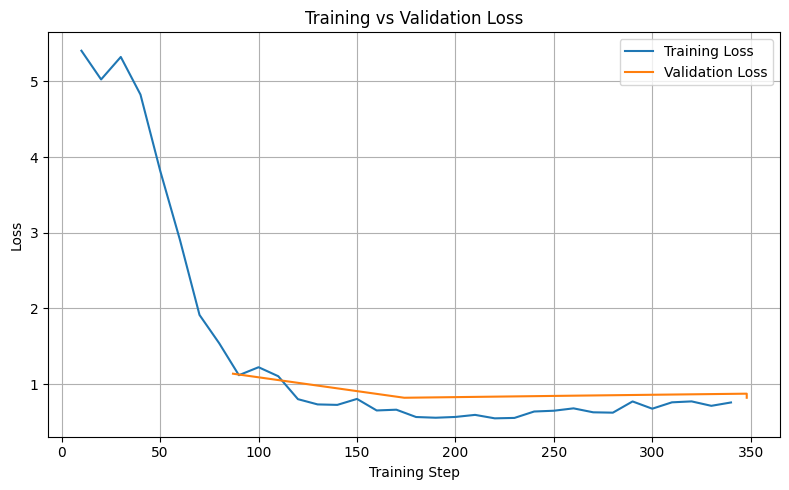

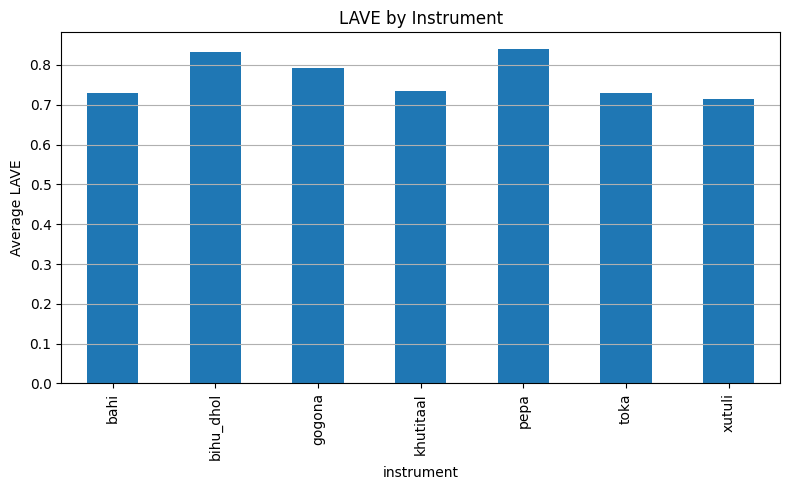

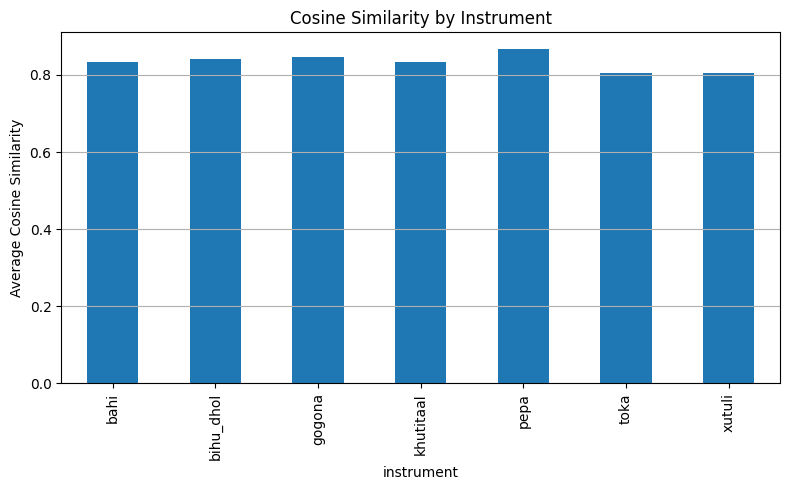

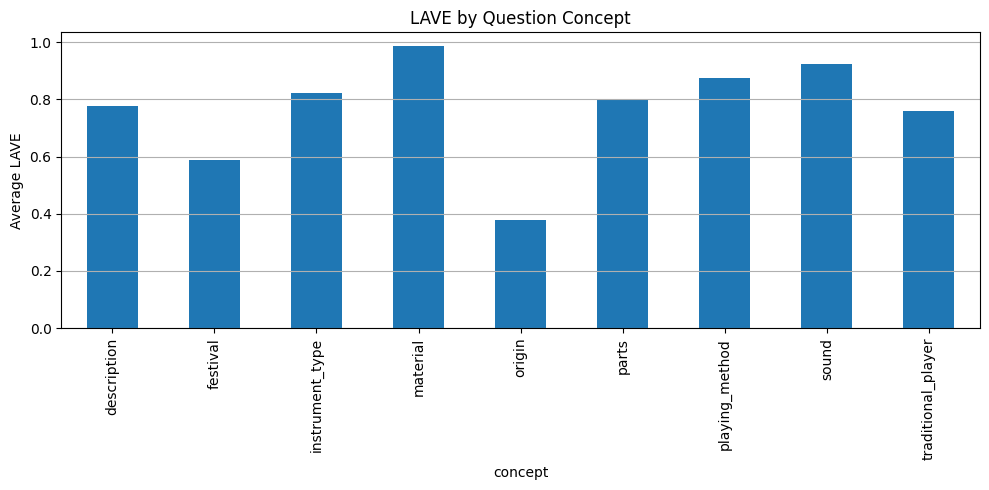

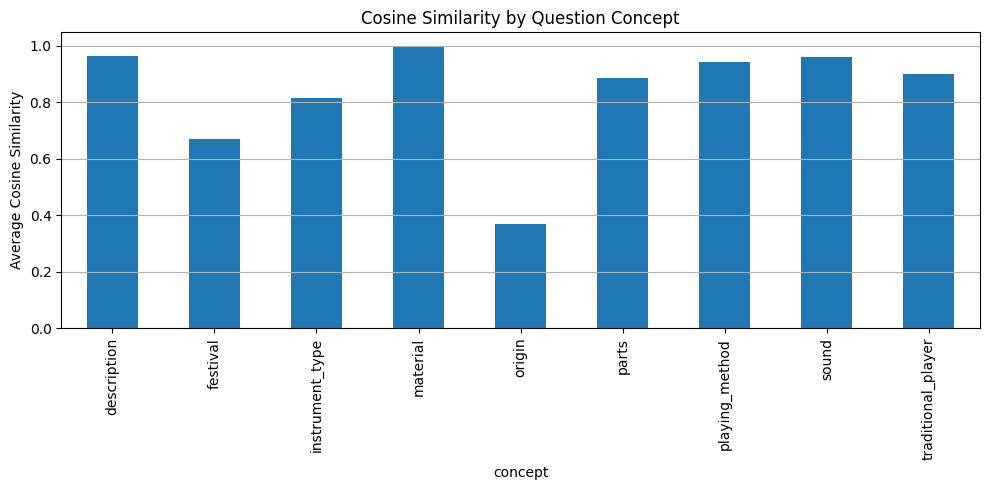

<Figure size 600x500 with 0 Axes>

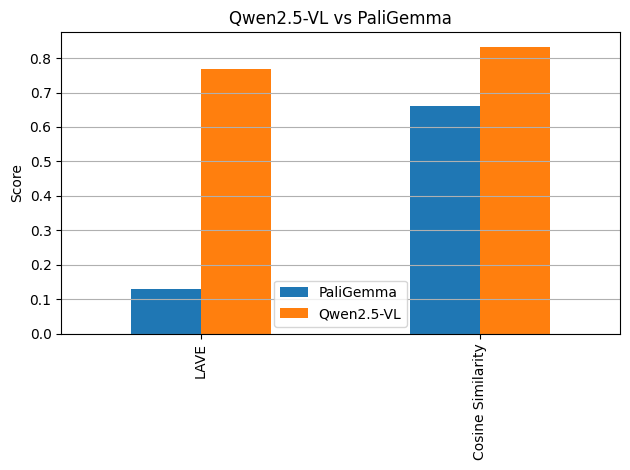

Overall LAVE : 0.7675
Overall Cosine Similarity : 0.8333
LAVE Improvement : 490.35%
Cosine Improvement : 26.26%

Instrument-wise Performance
            lave_score  cosine_similarity
instrument                               
bahi          0.728889           0.833943
bihu_dhol     0.833333           0.842089
gogona        0.792222           0.846445
khutitaal     0.735556           0.833017
pepa          0.840000           0.867220
toka          0.728889           0.804593
xutuli        0.713333           0.805956

Concept-wise Performance
                    lave_score  cosine_similarity
concept                                          
description           0.775714           0.962342
festival              0.588571           0.667972
instrument_type       0.822857           0.815696
material              0.985714           0.997290
origin                0.377143           0.369768
parts                 0.801429           0.886641
playing_method        0.874286           0.940812
sound

In [ ]:
# Import required libraries
import json
import pandas as pd
import matplotlib.pyplot as plt

# Define file paths
TRAINER_STATE="/kaggle/working/qwen2.5vl_lora/trainer_state.json"
LAVE_RESULTS="/kaggle/working/lave_results.json"
COSINE_RESULTS="/kaggle/working/cosine_results.json"

# Define PaliGemma baseline
PALIGEMMA_COSINE=0.66
PALIGEMMA_LAVE=0.13

# Load trainer state
with open(TRAINER_STATE,"r",encoding="utf-8") as f:
    trainer_state=json.load(f)

# Load evaluation results
with open(LAVE_RESULTS,"r",encoding="utf-8") as f:
    lave_results=pd.DataFrame(json.load(f))

with open(COSINE_RESULTS,"r",encoding="utf-8") as f:
    cosine_results=pd.DataFrame(json.load(f))

# Extract training and validation loss
train_loss=[]
train_steps=[]

eval_loss=[]
eval_steps=[]

for log in trainer_state["log_history"]:

    if "loss" in log:
        train_steps.append(log["step"])
        train_loss.append(log["loss"])

    if "eval_loss" in log:
        eval_steps.append(log["step"])
        eval_loss.append(log["eval_loss"])

# Compute overall metrics
overall_lave=lave_results["lave_score"].mean()
overall_cosine=cosine_results["cosine_similarity"].mean()

best_checkpoint=trainer_state["best_model_checkpoint"]
best_metric=trainer_state["best_metric"]

print(f"Best Checkpoint : {best_checkpoint}")
print(f"Best Validation Loss : {best_metric:.4f}")

# Merge evaluation results
merged=lave_results.merge(
    cosine_results[
        [
            "instrument",
            "question_id",
            "question",
            "cosine_similarity"
        ]
    ],
    on=[
        "instrument",
        "question_id",
        "question"
    ]
)

# Compute per-instrument metrics
instrument_scores=merged.groupby("instrument")[["lave_score","cosine_similarity"]].mean()

instrument_scores.to_csv(
    "/kaggle/working/instrument_scores.csv"
)

# Compute per-concept metrics
concept_scores=merged.groupby("concept")[["lave_score","cosine_similarity"]].mean()

concept_scores.to_csv(
    "/kaggle/working/concept_scores.csv"
)

# Compute improvement over baseline
lave_improvement=((overall_lave-PALIGEMMA_LAVE)/PALIGEMMA_LAVE)*100
cosine_improvement=((overall_cosine-PALIGEMMA_COSINE)/PALIGEMMA_COSINE)*100

# Select best and worst predictions
best_predictions=merged.sort_values("lave_score",ascending=False).head(5)

worst_predictions=merged.sort_values("lave_score").head(5)

# Plot training and validation loss
plt.figure(figsize=(8,5))
plt.plot(train_steps,train_loss,label="Training Loss")
plt.plot(eval_steps,eval_loss,label="Validation Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/loss_curve.png",dpi=300)
plt.show()

# Plot instrument-wise LAVE
plt.figure(figsize=(8,5))
instrument_scores["lave_score"].plot(kind="bar")
plt.ylabel("Average LAVE")
plt.title("LAVE by Instrument")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("/kaggle/working/instrument_lave.png",dpi=300)
plt.show()

# Plot instrument-wise cosine similarity
plt.figure(figsize=(8,5))
instrument_scores["cosine_similarity"].plot(kind="bar")
plt.ylabel("Average Cosine Similarity")
plt.title("Cosine Similarity by Instrument")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("/kaggle/working/instrument_cosine.png",dpi=300)
plt.show()

# Plot concept-wise LAVE
plt.figure(figsize=(10,5))
concept_scores["lave_score"].plot(kind="bar")
plt.ylabel("Average LAVE")
plt.title("LAVE by Question Concept")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("/kaggle/working/concept_lave.png",dpi=300)
plt.show()

# Plot concept-wise cosine similarity
plt.figure(figsize=(10,5))
concept_scores["cosine_similarity"].plot(kind="bar")
plt.ylabel("Average Cosine Similarity")
plt.title("Cosine Similarity by Question Concept")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("/kaggle/working/concept_cosine.png",dpi=300)
plt.show()

# Plot baseline comparison
comparison=pd.DataFrame({
    "PaliGemma":[PALIGEMMA_LAVE,PALIGEMMA_COSINE],
    "Qwen2.5-VL":[overall_lave,overall_cosine]
},index=["LAVE","Cosine Similarity"])

plt.figure(figsize=(6,5))
comparison.plot(kind="bar")
plt.ylabel("Score")
plt.title("Qwen2.5-VL vs PaliGemma")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("/kaggle/working/baseline_comparison.png",dpi=300)
plt.show()

# Display summary
print(f"Overall LAVE : {overall_lave:.4f}")
print(f"Overall Cosine Similarity : {overall_cosine:.4f}")
print(f"LAVE Improvement : {lave_improvement:.2f}%")
print(f"Cosine Improvement : {cosine_improvement:.2f}%")

print("\nInstrument-wise Performance")
print(instrument_scores)

print("\nConcept-wise Performance")
print(concept_scores)

print("\nTop 5 Best Predictions")
print(best_predictions[[
    "instrument",
    "concept",
    "question",
    "prediction",
    "ground_truth",
    "lave_score",
    "cosine_similarity"
]])

print("\nTop 5 Worst Predictions")
print(worst_predictions[[
    "instrument",
    "concept",
    "question",
    "prediction",
    "ground_truth",
    "lave_score",
    "cosine_similarity"
]])